In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 0.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.11675931 Ha
FCI能量: -1.13728383 Ha


SpinOrbitalFermions 是 NetKet（特别是 netket ≥ v3.10 之后，或通过 netket.experimental）中用于描述具有自旋的费米子系统的希尔伯特空间（Hilbert space）类。它专为处理电子结构问题（如分子、固体中的多电子系统）而设计，天然支持泡利不相容原理和固定粒子数约束。

SpinOrbitalFermions 定义了一个由自旋轨道占据数构成的离散希尔伯特空间，每个自旋轨道只能被占据（1）或空（0），且满足：

费米子统计（自动通过占据数表示处理）
可选：固定总电子数、固定自旋向上/向下电子数


In [2]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
# 对于分子系统，我们使用完整的轨道图（完全连接）
# cluster = [(0,1),(2,3)]
#
g = nk.graph.Graph(edges=[(0,2),(1,3)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [ ]:

# 创建变分量子态 - 使用Slater行列式作为初始波函数
ma = nk.models.RBM(alpha=2, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01, holomorphic=True)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h2_molecule"

In [4]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:33<00:00,  8.85it/s, Energy=-1.12445-0.00000j ± 0.00044 [σ²=0.00010, R̂=1.4031]]


(JsonLog('h2_molecule', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.14315032958984375
   	Params: 0.13848519325256348,)

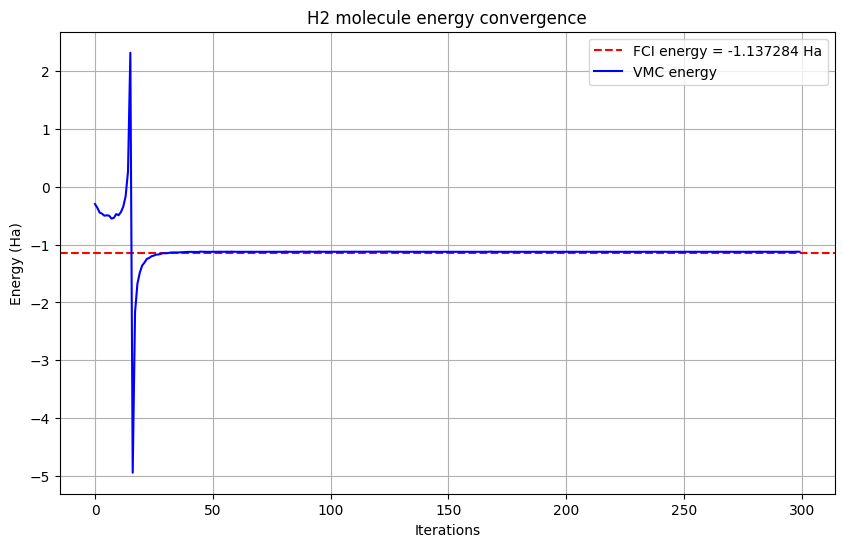


最终VMC能量: -1.12445265 Ha
与FCI能量误差: 0.01283118 Ha


In [13]:
############## 绘图 #################

# 获取精确对角化能量（FCI能量）
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H2 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"\n最终VMC能量: {y[-1]:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")
